# Iniciación de paquetes

In [2]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
historial_metricas = pd.DataFrame()

# Métricas iniciales

In [3]:
import math

def metricas_estaticas(clientes, horas, mu, s, cs=0, cq=0):
   
    lambda_tasa = clientes / horas
    rho = lambda_tasa / (s * mu)
    

    if rho >= 1:
        return {"error": "Sistema inestable (rho >= 1)"}


    termino_sumatorio = sum([(lambda_tasa/mu)**n / math.factorial(n) for n in range(s)])
    termino_cola = ((lambda_tasa/mu)**s / (math.factorial(s) * (1 - rho)))
    pi0 = 1 / (termino_sumatorio + termino_cola)
    
  
    Lq = (pi0 * ((lambda_tasa/mu)**s) * rho) / (math.factorial(s) * (1 - rho)**2)
    Wq = Lq / lambda_tasa
    W = Wq + (1/mu)
    L = lambda_tasa * W
    
    
    Cts = (cs * s) + (cq * Lq)
    
    # Devolvemos un diccionario con todo
    return {
        "rho": round(rho, 3),
        "Lq": round(Lq, 3),
        "Wq_min": round(Wq*60, 3),
        "L": round(L, 3),
        "Cts": round(Cts, 3),
        "lambda": round(lambda_tasa, 3),
        "horas": horas,
        "clientes": clientes,
        "mu": mu,
        "servidores": s
    }

Aún no nos interesa la optimización del dinero, de momento vamos a fijarnos en los factores de utilización y ocupacion de las colas

In [21]:
metricas_teoricas = metricas_estaticas(120, 8, 3, 7)
print(metricas_teoricas)
metricas_teoricas6 = metricas_estaticas(70, 8, 3, 7)
metricas_teoricas5 = metricas_estaticas(70, 8, 3, 5)
print(metricas_teoricas5)


{'rho': 0.714, 'Lq': 0.81, 'Wq_min': 3.241, 'L': 5.81, 'Cts': 0.0, 'lambda': 15.0, 'horas': 8, 'clientes': 120, 'mu': 3, 'servidores': 7}
{'rho': 0.583, 'Lq': 0.302, 'Wq_min': 2.074, 'L': 3.219, 'Cts': 0.0, 'lambda': 8.75, 'horas': 8, 'clientes': 70, 'mu': 3, 'servidores': 5}


# Función de simulación de llegadas y salidas

In [5]:
import numpy as np
import pandas as pd

def generacion_llegadas(lambda_base, pesos_horarios):
    tiempos = []
    t = 0.0
    for hora, peso in enumerate(pesos_horarios):
        tasa = lambda_base * peso
        # mueve el reloj al inicio exacto de la hora
        t = float(hora)

        if tasa <= 0:
            continue

        while True:
            t += np.random.exponential(1 / tasa)
            if t >= hora + 1:
                break
            tiempos.append(t)

    return tiempos

def simulacion_atencion(asesores, llegadas):
    
    disponibilidad = [0.0] * len(asesores)
    esperas = []
    for llegada in llegadas:
        libre = min(disponibilidad)
        idx = disponibilidad.index(libre)
        inicio = max(llegada, libre)
        esperas.append(inicio - llegada)
        # El mu depende del asesor específico asignado
        t_serv = np.random.exponential(1 / asesores[idx]['mu'])
        disponibilidad[idx] = inicio + t_serv
    return esperas

def simulacion_total(n_iteraciones, lambda_base, pesos, lista_asesores, coste_espera_h):
    
    record_wq = []
    record_costes_espera = []
    
    # Coste fijo de los salarios (Suma de costes/h * 8 horas)
    coste_fijo_asesores = sum([a['coste'] for a in lista_asesores]) * len(pesos)

    lambda_media = lambda_base * np.mean(pesos)
    capacidad_total = sum(a['mu'] for a in lista_asesores)
    rho = lambda_media / capacidad_total

    
    for _ in range(n_iteraciones):
        llegadas = generacion_llegadas(lambda_base, pesos)
        esperas = simulacion_atencion(lista_asesores, llegadas)
        
        if esperas:
            wq_dia = np.mean(esperas)
            coste_espera_dia = sum(esperas) * coste_espera_h
            record_wq.append(wq_dia * 60) # Pasamos a minutos
            record_costes_espera.append(coste_espera_dia)

    # Consolidación Estadística
    return {
        "Wq Medio (min)": round(np.mean(record_wq), 2),
        "Incertidumbre (Std Dev min)": round(np.std(record_wq), 2),
        "Coste Salarios (€/día)": coste_fijo_asesores,
        "Coste Espera Medio (€/día)": round(np.mean(record_costes_espera), 2),
        "Coste Total Medio (€/día)": round(coste_fijo_asesores + np.mean(record_costes_espera), 2),
        "Factor de utilización medio": rho
    }

def registrar_experimento(nombre_escenario, n_iteraciones, lambda_base, pesos, lista_asesores, coste_wait_h):
    """
    Ejecuta la simulación y devuelve un DataFrame con los parámetros y resultados aplanados.
    """
    # 1. Ejecutar tu lógica original
    res = simulacion_total(n_iteraciones, lambda_base, pesos, lista_asesores, coste_wait_h)
    
    # 2. Crear el diccionario de parámetros de entrada
    # Calculamos el mu promedio del equipo para tener una referencia rápida
    mu_promedio = np.mean([a['mu'] for a in lista_asesores])
    
    config = {
        "Escenario": nombre_escenario,
        "Iteraciones": n_iteraciones,
        "Lambda Base": lambda_base,
        "Num Asesores": len(lista_asesores),
        "Mu Promedio": round(mu_promedio, 2),
        "Coste Espera (€/h)": coste_wait_h,
        "Configuración": f"L={lambda_base}, S={len(lista_asesores)}, Mu={round(mu_promedio,1)}"
    }
    
    # 3. Fusionar Configuración + Resultados en un solo registro
    # Usamos el operador unpacking ** para unir ambos diccionarios
    registro_completo = {**config, **res}
    
    return pd.DataFrame([registro_completo])

# Configuración de equipos

# Equipos base

In [6]:
# Definimos los escenarios a probar
config_asesores_7 = [
    {'nombre': '1', 'mu': 3, 'coste': 20},
    {'nombre': '2', 'mu': 3, 'coste': 20},
    {'nombre': '3', 'mu': 3, 'coste': 20},
    {'nombre': '4', 'mu': 3, 'coste': 20},
    {'nombre': '5', 'mu': 3, 'coste': 20},
    {'nombre': '6', 'mu': 3, 'coste': 20},
    {'nombre': '7', 'mu': 3, 'coste': 20}
] # Equipo de 7 miembros con mu constante

config_asesores_6 = [
    {'nombre': '1', 'mu': 3, 'coste': 20},
    {'nombre': '2', 'mu': 3, 'coste': 20},
    {'nombre': '3', 'mu': 3, 'coste': 20},
    {'nombre': '4', 'mu': 3, 'coste': 20},
    {'nombre': '5', 'mu': 3, 'coste': 20},
    {'nombre': '6', 'mu': 3, 'coste': 20}
] # Equipo de 6 miembros con mu constante

config_asesores_5 = [
    {'nombre': '1', 'mu': 3, 'coste': 20},
    {'nombre': '2', 'mu': 3, 'coste': 20},
    {'nombre': '3', 'mu': 3, 'coste': 20},
    {'nombre': '4', 'mu': 3, 'coste': 20},
    {'nombre': '5', 'mu': 3, 'coste': 20}
] # Equipo de 5 miembros con mu constante

config_asesores_8 = [
    {'nombre': '1', 'mu': 3, 'coste': 20},
    {'nombre': '2', 'mu': 3, 'coste': 20},
    {'nombre': '3', 'mu': 3, 'coste': 20},
    {'nombre': '4', 'mu': 3, 'coste': 20},
    {'nombre': '5', 'mu': 3, 'coste': 20},
    {'nombre': '6', 'mu': 3, 'coste': 20},
    {'nombre': '7', 'mu': 3, 'coste': 20},
    {'nombre': '8', 'mu': 3, 'coste': 20}
] # Equipo de 8 miembros con mu constante

config_asesores_9 = [
    {'nombre': '1', 'mu': 3, 'coste': 20},
    {'nombre': '2', 'mu': 3, 'coste': 20},
    {'nombre': '3', 'mu': 3, 'coste': 20},
    {'nombre': '4', 'mu': 3, 'coste': 20},
    {'nombre': '5', 'mu': 3, 'coste': 20},
    {'nombre': '6', 'mu': 3, 'coste': 20},
    {'nombre': '7', 'mu': 3, 'coste': 20},
    {'nombre': '8', 'mu': 3, 'coste': 20},
    {'nombre': '9', 'mu': 3, 'coste': 20}
] # Equipo de 9 miembros con mu constante

# Equipos mixtos

In [7]:
# Definimos los escenarios a probar
config_asesores_7_mixtos_1 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
] 

config_asesores_7_mixtos_2 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
]

config_asesores_8_mixtos_1 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
] 

config_asesores_8_mixtos_2 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
] 

config_asesores_6_mixtos_1 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
]

config_asesores_6_mixtos_2 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
]

config_asesores_4_senior = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
]

config_asesores_5_senior = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
]

config_asesores_6_senior = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
]

config_asesores_8_junior = [
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
]

# Variables de resultados

## Resultados en escenarios de barrido de staff en días intermedios

In [8]:
experimentos1 = []
pesos_dia = [1.3, 1.2, 1.0, 0.7, 1.0, 1.3, 1.2, 0.8] # 8 horas

# Escenario 1
experimentos1.append(registrar_experimento("Base (9 asesores)", 500, 15, pesos_dia, config_asesores_9, 35))

# Escenario 2
experimentos1.append(registrar_experimento("Base (8 asesores)", 500, 15, pesos_dia, config_asesores_8, 35))

# Escenario 3
experimentos1.append(registrar_experimento("Base (7 asesores)", 500, 15, pesos_dia, config_asesores_7, 35))

# Escenario 4
experimentos1.append(registrar_experimento("Base (6 asesores)", 500, 15, pesos_dia, config_asesores_6, 35))

# Escenario 5
experimentos1.append(registrar_experimento("Base (5 asesores)", 500, 15, pesos_dia, config_asesores_5, 35))

# Escenario 6
experimentos1.append(registrar_experimento("Alta demanda (6 asesores)", 500, 20, pesos_dia, config_asesores_6, 35))

# Escenario 7
experimentos1.append(registrar_experimento("Alta demanda (7 asesores)", 500, 20, pesos_dia, config_asesores_7, 35))

# Escenario 8
experimentos1.append(registrar_experimento("Alta demanda (8 asesores)", 500, 20, pesos_dia, config_asesores_8, 35))

# Consolidamos todo en el DataFrame maestro
df_barrido_staff = pd.concat(experimentos1, ignore_index=True)

# Ahora puedes ver todo limpio
display(df_barrido_staff)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Base (9 asesores),500,15,9,3.0,35,"L=15, S=9, Mu=3.0",0.73,1.11,1440,56.44,1496.44,0.590278
1,Base (8 asesores),500,15,8,3.0,35,"L=15, S=8, Mu=3.0",1.87,2.26,1280,145.37,1425.37,0.664062
2,Base (7 asesores),500,15,7,3.0,35,"L=15, S=7, Mu=3.0",4.37,4.13,1120,336.68,1456.68,0.758929
3,Base (6 asesores),500,15,6,3.0,35,"L=15, S=6, Mu=3.0",11.99,10.17,960,932.70,1892.70,0.885417
4,Base (5 asesores),500,15,5,3.0,35,"L=15, S=5, Mu=3.0",32.98,21.95,800,2539.78,3339.78,1.062500
5,Alta demanda (6 asesores),500,20,6,3.0,35,"L=20, S=6, Mu=3.0",50.19,27.03,960,5128.30,6088.30,1.180556
6,Alta demanda (7 asesores),500,20,7,3.0,35,"L=20, S=7, Mu=3.0",22.31,16.44,1120,2274.26,3394.26,1.011905
7,Alta demanda (8 asesores),500,20,8,3.0,35,"L=20, S=8, Mu=3.0",10.24,8.64,1280,1055.04,2335.04,0.885417


Aquí podemos observar que el dilema es si tenemos 7 asesores para todo el año que rinden bien para situaciones equilibradas u 8 que funcionan bien incluso en momentos de alta demanda

## Resultados en escenarios variados con distintos tipos de equipos mixtos

In [9]:
experimentos2 = []

# Demanda base

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (4 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (4 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_1, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (3 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_2, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (3 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_6_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_6_mixtos_1, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (2 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_6_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (2 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_6_mixtos_2, 35))

# Escenario 5:
experimentos2.append(registrar_experimento("Mixto (4 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (4 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_1, 35))

# Escenario 5:
experimentos2.append(registrar_experimento("Mixto (3 senior / 5 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 5 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_2, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (6 senior) base", 500, 15, pesos_dia, config_asesores_6_senior, 35))
experimentos2.append(registrar_experimento("Senior (6 senior) alta demanda", 500, 20, pesos_dia, config_asesores_6_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (5 senior) base", 500, 15, pesos_dia, config_asesores_5_senior, 35))
experimentos2.append(registrar_experimento("Senior (5 senior) alta demanda", 500, 20, pesos_dia, config_asesores_5_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (4 senior) base", 500, 15, pesos_dia, config_asesores_4_senior, 35))
experimentos2.append(registrar_experimento("Senior (4 senior) alta demanda", 500, 20, pesos_dia, config_asesores_4_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Junior (8 junior) base", 500, 15, pesos_dia, config_asesores_8_junior, 35))
experimentos2.append(registrar_experimento("Junior (8 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_junior, 35))

# Consolidamos todo en el DataFrame maestro
df_Equipos_mixtos1 = pd.concat(experimentos2, ignore_index=True)

# Ahora puedes ver todo limpio
display(df_Equipos_mixtos1)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.36,2.44,1320,182.01,1502.01,0.678191
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",11.86,9.13,1320,1210.03,2530.03,0.904255
2,Mixto (3 senior / 4 junior) base,500,15,7,3.14,35,"L=15, S=7, Mu=3.1",3.95,4.49,1200,308.40,1508.40,0.724432
3,Mixto (3 senior / 4 junior) alta demanda,500,20,7,3.14,35,"L=20, S=7, Mu=3.1",16.92,13.15,1200,1731.38,2931.38,0.965909
4,Mixto (3 senior / 3 junior) base,500,15,6,3.25,35,"L=15, S=6, Mu=3.2",7.39,6.65,1080,574.37,1654.37,0.817308
5,Mixto (3 senior / 3 junior) alta demanda,500,20,6,3.25,35,"L=20, S=6, Mu=3.2",33.76,21.76,1080,3433.32,4513.32,1.089744
6,Mixto (2 senior / 4 junior) base,500,15,6,3.00,35,"L=15, S=6, Mu=3.0",12.53,10.92,960,981.36,1941.36,0.885417
7,Mixto (2 senior / 4 junior) alta demanda,500,20,6,3.00,35,"L=20, S=6, Mu=3.0",52.29,27.35,960,5303.72,6263.72,1.180556
8,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.22,1.77,1440,95.09,1535.09,0.612981
9,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.48,4.85,1440,561.70,2001.70,0.817308


A vista del dataframe es evidente que los dos que serían mas optimos son los mixtos establecidos aquí debajo

In [10]:
experimentos3 = []

# Escenario 1
experimentos3.append(registrar_experimento("Mixto (4 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_1, 35))
experimentos3.append(registrar_experimento("Mixto (4 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_1, 35))

# Escenario 5:
experimentos3.append(registrar_experimento("Mixto (4 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_1, 35))
experimentos3.append(registrar_experimento("Mixto (4 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_1, 35))

# Escenario 5:
experimentos3.append(registrar_experimento("Mixto (3 senior / 5 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_2, 35))
experimentos3.append(registrar_experimento("Mixto (3 senior / 5 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_2, 35))

# Consolidamos todo en el DataFrame maestro
df_Equipos_mixtos2 = pd.concat(experimentos3, ignore_index=True)

# Ahora puedes ver todo limpio
display(df_Equipos_mixtos2)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.46,3.00,1320,192.77,1512.77,0.678191
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",11.52,10.25,1320,1186.89,2506.89,0.904255
2,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.26,1.65,1440,99.27,1539.27,0.612981
3,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.71,4.97,1440,582.81,2022.81,0.817308
4,Mixto (3 senior / 5 junior) base,500,15,8,3.06,35,"L=15, S=8, Mu=3.1",1.56,1.91,1320,121.91,1441.91,0.650510
5,Mixto (3 senior / 5 junior) alta demanda,500,20,8,3.06,35,"L=20, S=8, Mu=3.1",9.14,7.69,1320,939.45,2259.45,0.867347


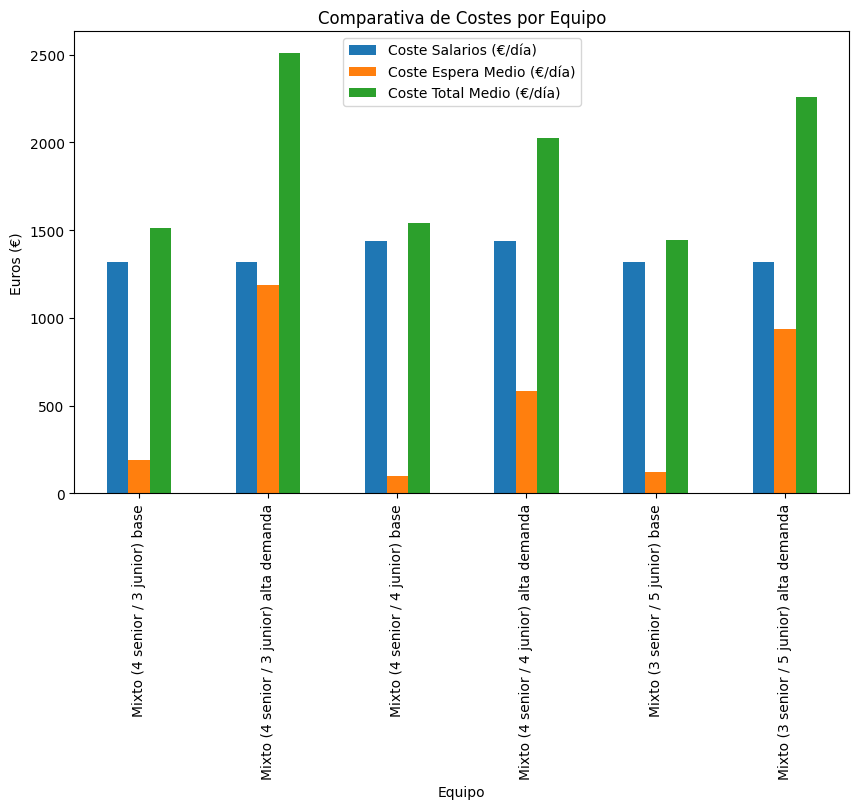

In [11]:
import matplotlib.pyplot as plt

# 1. Seleccionamos las columnas que nos interesan para comparar costes
# Usamos el nombre del dataframe que tienes en tu notebook: df_Equipos_mixtos2
columnas_costes = ['Escenario', 'Coste Salarios (€/día)', 'Coste Espera Medio (€/día)', 'Coste Total Medio (€/día)']
df_Equipos_mixtos_simple = df_Equipos_mixtos2[columnas_costes]

# 2. Creamos la gráfica de barras
# .set_index('Escenario') hace que los nombres de los equipos salgan abajo
df_Equipos_mixtos_simple.set_index('Escenario').plot(kind='bar', figsize=(10, 6))

# 3. Ponemos títulos básicos para que se entienda
plt.title("Comparativa de Costes por Equipo")
plt.ylabel("Euros (€)")
plt.xlabel("Equipo")

# 4. Mostrar la gráfica
plt.show()

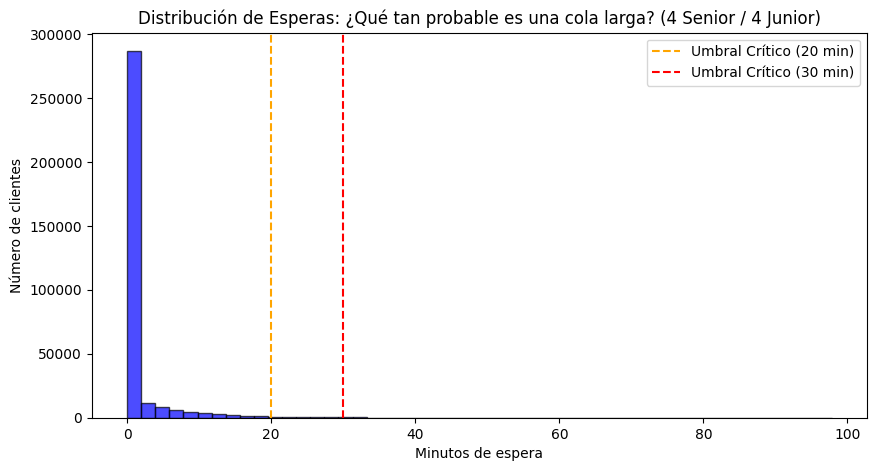

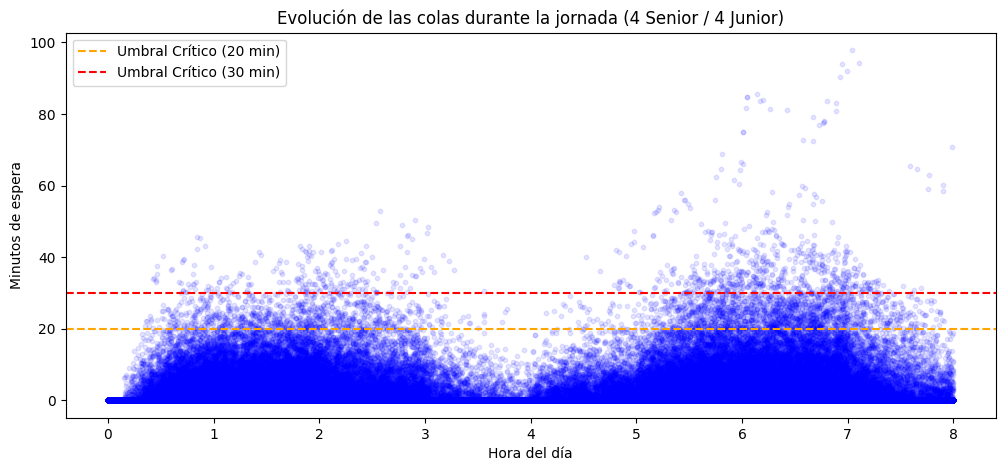

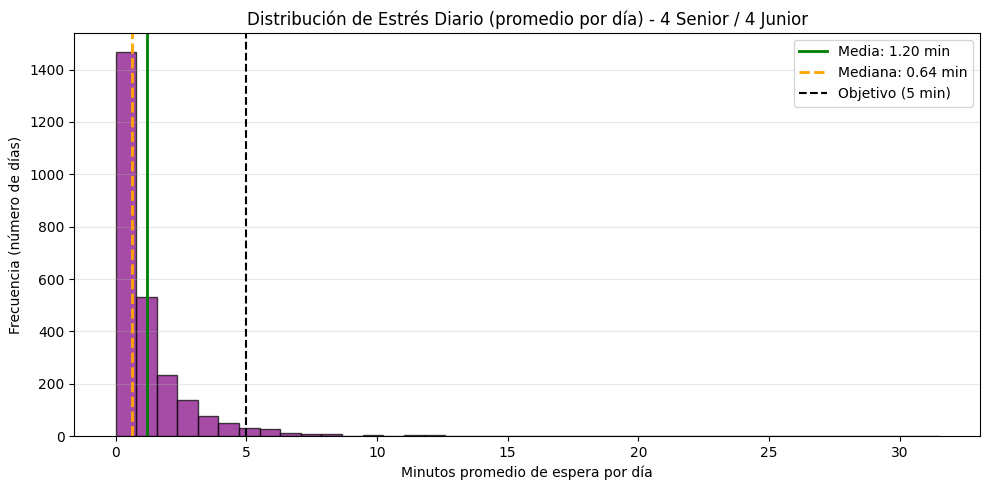

--- ANÁLISIS DE RIESGO (Individual) ---
- Probabilidad de que un cliente espere más de 20 min: 1.07%
- Probabilidad de que un cliente espere más de 30 min: 0.26%

--- ANÁLISIS DE ESTRÉS DIARIO ---
Media de estrés diario: 1.20 min
Mediana de estrés diario: 0.64 min
Desviación estándar: 1.67 min
Mínimo (mejor día): 0.00 min
Máximo (peor día): 31.50 min
Días con estrés > 5 min: 91 de 2600

--- ANÁLISIS GLOBAL ---
Total de personas atendidas: 331255
Total de personas que esperaron menos de 5 min: 302831
Total de personas que esperaron menos de 10 min: 317308
Porcentaje de satisfacción (espera < 10 min): 95.79%


In [17]:
# Umbrales críticos
umbral_critico1 = 20  
umbral_critico2 = 30  
equipo_analizar = config_asesores_8_mixtos_1
n_jornadas = 2600

total_personas_espera_larga = 0
total_personas_atendidas = 0
total_personas_espera_corta5 = 0
total_personas_espera_corta10 = 0

resultados_por_dia = []
todas_las_esperas = []
esperas_por_hora = []

# Simulación de cada jornada (UN SOLO BUCLE)
for _ in range(n_jornadas): 
    llegadas = generacion_llegadas(15, pesos_dia) 
    esperas = simulacion_atencion(equipo_analizar, llegadas)
    
    # Guardamos datos por cliente
    for t_llegada, espera in zip(llegadas, esperas):
        espera_min = espera * 60
        todas_las_esperas.append(espera_min)
        esperas_por_hora.append({'Hora': t_llegada, 'Espera': espera_min})
    
    # Estadísticas del día
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # Guardamos el promedio del día para la gráfica
        promedio_dia = sum(esperas_minutos) / len(esperas_minutos)
        resultados_por_dia.append(promedio_dia)
        
        # Estadísticas de satisfacción
        gente_hoy_espera_menos_5 = sum(1 for m in esperas_minutos if m < 5)
        gente_hoy_espera_menos_10 = sum(1 for m in esperas_minutos if m < 10)
        
        # Acumulamos totales
        total_personas_espera_corta5 += gente_hoy_espera_menos_5
        total_personas_espera_corta10 += gente_hoy_espera_menos_10
        total_personas_atendidas += len(llegadas)
    else:
        # Si no hubo esperas, el tiempo es 0
        resultados_por_dia.append(0)

df_detallado = pd.DataFrame(esperas_por_hora)

# --- 1. ¿CADA CUÁNTO HAY COLAS LARGAS? (Histograma de Riesgo) ---
plt.figure(figsize=(10, 5))
plt.hist(todas_las_esperas, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axvline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.title("Distribución de Esperas: ¿Qué tan probable es una cola larga? (4 Senior / 4 Junior)")
plt.xlabel("Minutos de espera")
plt.ylabel("Número de clientes")
plt.legend()
plt.show()

# Gráfica de espera en cola por cliente 
plt.figure(figsize=(12, 5))
plt.scatter(df_detallado['Hora'], df_detallado['Espera'], alpha=0.1, color='blue', s=10)
plt.title("Evolución de las colas durante la jornada (4 Senior / 4 Junior)")
plt.xlabel("Hora del día")
plt.ylabel("Minutos de espera")
plt.axhline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axhline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.xticks(range(9)) # Para ver las 8 horas de jornada
plt.legend()
plt.show()

# --- HISTOGRAMA DE ESTRÉS DIARIO (Distribución de promedios diarios) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de distribución de promedios diarios
ax.hist(resultados_por_dia, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(resultados_por_dia), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(resultados_por_dia):.2f} min')
ax.axvline(np.median(resultados_por_dia), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(resultados_por_dia):.2f} min')
ax.axvline(5, color='black', linestyle='--', label='Objetivo (5 min)')
ax.set_title("Distribución de Estrés Diario (promedio por día) - 4 Senior / 4 Junior")
ax.set_xlabel("Minutos promedio de espera por día")
ax.set_ylabel("Frecuencia (número de días)")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- MÉTRICAS DE CALIDAD DE SERVICIO (SLA) ---
prob_larga20 = (np.array(todas_las_esperas) > umbral_critico1).mean() * 100
prob_larga30 = (np.array(todas_las_esperas) > umbral_critico2).mean() * 100

print(f"--- ANÁLISIS DE RIESGO (Individual) ---")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico1} min: {prob_larga20:.2f}%")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico2} min: {prob_larga30:.2f}%")

print(f"\n--- ANÁLISIS DE ESTRÉS DIARIO ---")
print(f"Media de estrés diario: {np.mean(resultados_por_dia):.2f} min")
print(f"Mediana de estrés diario: {np.median(resultados_por_dia):.2f} min")
print(f"Desviación estándar: {np.std(resultados_por_dia):.2f} min")
print(f"Mínimo (mejor día): {np.min(resultados_por_dia):.2f} min")
print(f"Máximo (peor día): {np.max(resultados_por_dia):.2f} min")
print(f"Días con estrés > 5 min: {sum(1 for x in resultados_por_dia if x > 5)} de {n_jornadas}")

print(f"\n--- ANÁLISIS GLOBAL ---")
print(f"Total de personas atendidas: {total_personas_atendidas}")
print(f"Total de personas que esperaron menos de 5 min: {total_personas_espera_corta5}")
print(f"Total de personas que esperaron menos de 10 min: {total_personas_espera_corta10}")

if total_personas_atendidas > 0:
    satisfaccion = (total_personas_espera_corta10 / total_personas_atendidas) * 100
    print(f"Porcentaje de satisfacción (espera < 10 min): {satisfaccion:.2f}%")


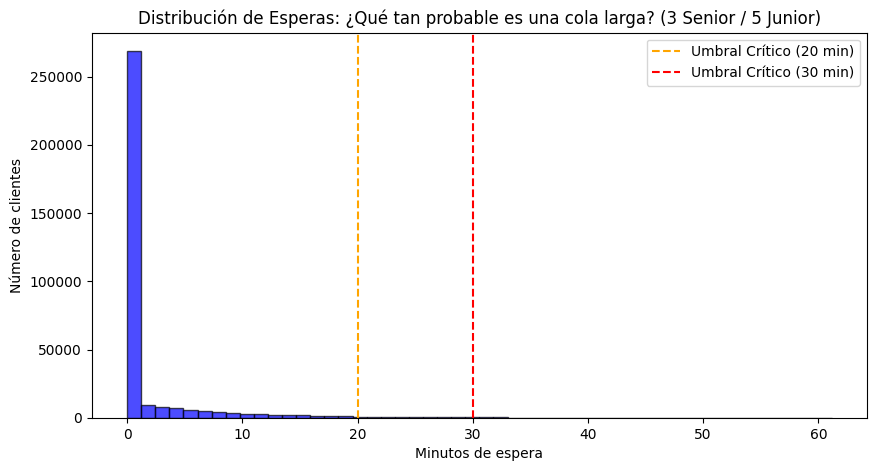

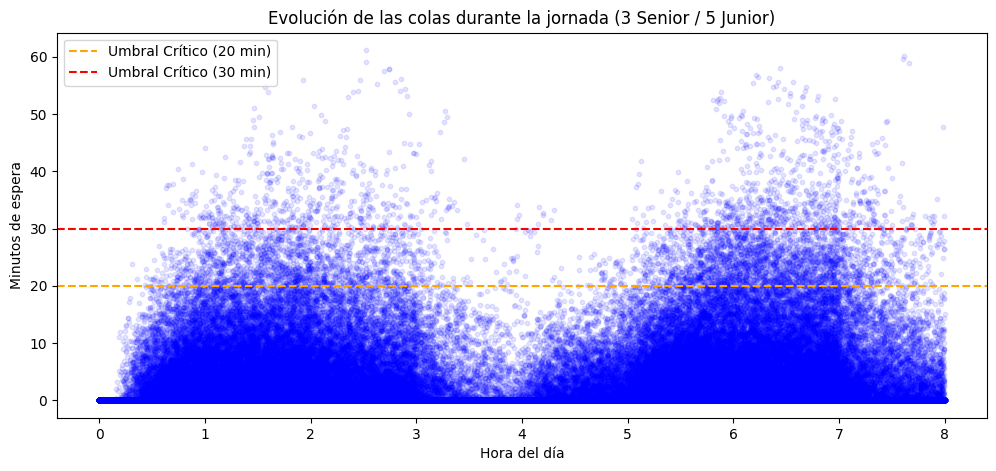

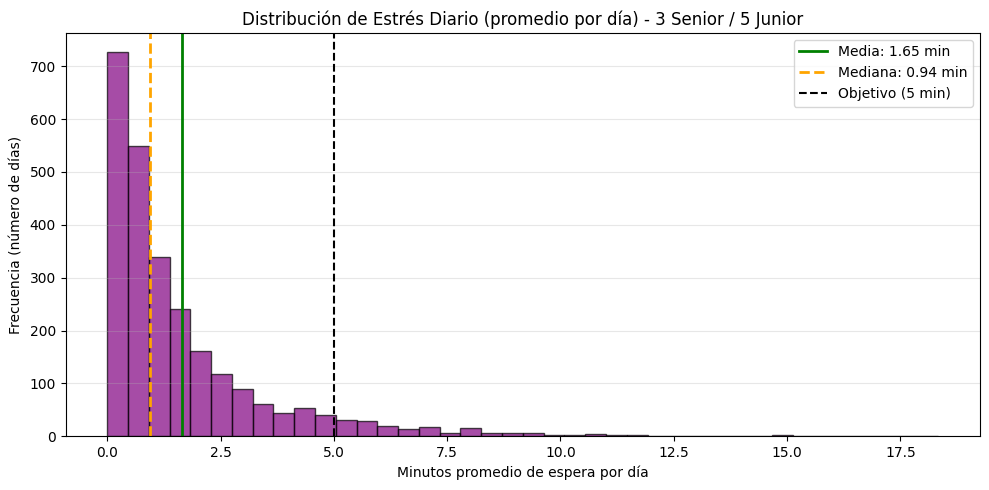

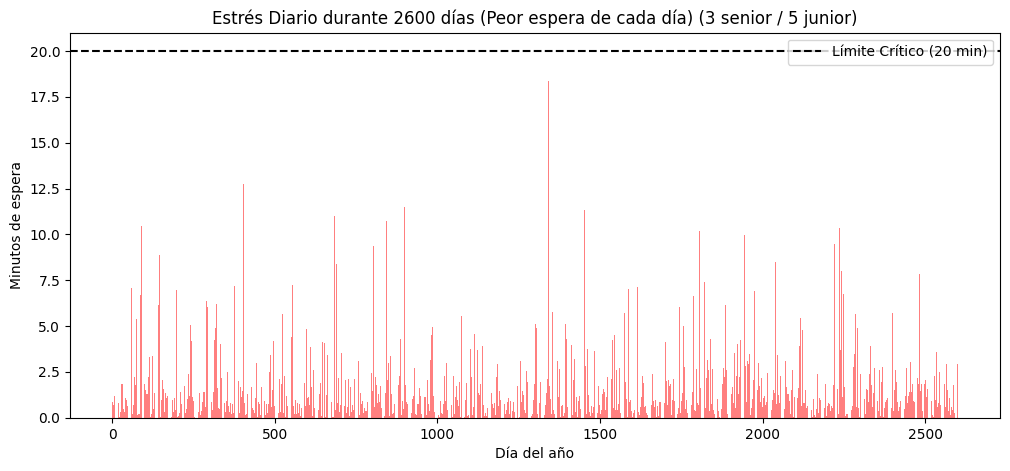

--- ANÁLISIS DE RIESGO (Individual) ---
- Probabilidad de que un cliente espere más de 20 min: 1.73%
- Probabilidad de que un cliente espere más de 30 min: 0.42%

--- ANÁLISIS DE ESTRÉS DIARIO ---
Media de estrés diario: 1.65 min
Mediana de estrés diario: 0.94 min
Desviación estándar: 1.98 min
Mínimo (mejor día): 0.00 min
Máximo (peor día): 18.34 min
Días con estrés > 5 min: 182 de 2600
Días con al menos un 'colapso' (>20 min): 0 de 2600

--- ANÁLISIS GLOBAL ---
Total de personas atendidas: 331828
Total de personas que esperaron menos de 5 min: 293228
Total de personas que esperaron menos de 10 min: 311447
Total de personas que esperaron mas de 20 min: 5731
Porcentaje de satisfacción (espera < 10 min): 93.86%
Porcentaje de insatisfacción: 1.73%


In [13]:
# Umbrales críticos
umbral_critico1 = 20  
umbral_critico2 = 30  
equipo_analizar = config_asesores_8_mixtos_2
n_jornadas = 2600

total_personas_espera_larga = 0
total_personas_atendidas = 0
total_personas_espera_corta5 = 0
total_personas_espera_corta10 = 0

resultados_por_dia = []
todas_las_esperas = []
esperas_por_hora = []

# Simulación de cada jornada (UN SOLO BUCLE)
for _ in range(n_jornadas): 
    llegadas = generacion_llegadas(15, pesos_dia) 
    esperas = simulacion_atencion(equipo_analizar, llegadas)
    
    # Guardamos datos por cliente
    for t_llegada, espera in zip(llegadas, esperas):
        espera_min = espera * 60
        todas_las_esperas.append(espera_min)
        esperas_por_hora.append({'Hora': t_llegada, 'Espera': espera_min})
    
    # Estadísticas del día
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # Guardamos el promedio del día para la gráfica
        promedio_dia = sum(esperas_minutos) / len(esperas_minutos)
        resultados_por_dia.append(promedio_dia)
        
        # Estadísticas de satisfacción
        gente_hoy_espera_menos_5 = sum(1 for m in esperas_minutos if m < 5)
        gente_hoy_espera_menos_10 = sum(1 for m in esperas_minutos if m < 10)
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # Acumulamos totales
        total_personas_espera_corta5 += gente_hoy_espera_menos_5
        total_personas_espera_corta10 += gente_hoy_espera_menos_10
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        # Si no hubo esperas, el tiempo es 0
        resultados_por_dia.append(0)

df_detallado = pd.DataFrame(esperas_por_hora)

# --- 1. ¿CADA CUÁNTO HAY COLAS LARGAS? (Histograma de Riesgo) ---
plt.figure(figsize=(10, 5))
plt.hist(todas_las_esperas, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axvline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.title("Distribución de Esperas: ¿Qué tan probable es una cola larga? (3 Senior / 5 Junior)")
plt.xlabel("Minutos de espera")
plt.ylabel("Número de clientes")
plt.legend()
plt.show()

# Gráfica de espera en cola por cliente 
plt.figure(figsize=(12, 5))
plt.scatter(df_detallado['Hora'], df_detallado['Espera'], alpha=0.1, color='blue', s=10)
plt.title("Evolución de las colas durante la jornada (3 Senior / 5 Junior)")
plt.xlabel("Hora del día")
plt.ylabel("Minutos de espera")
plt.axhline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axhline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.xticks(range(9)) # Para ver las 8 horas de jornada
plt.legend()
plt.show()

# --- HISTOGRAMA DE ESTRÉS DIARIO (Distribución de promedios diarios) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de distribución de promedios diarios
ax.hist(resultados_por_dia, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(resultados_por_dia), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(resultados_por_dia):.2f} min')
ax.axvline(np.median(resultados_por_dia), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(resultados_por_dia):.2f} min')
ax.axvline(5, color='black', linestyle='--', label='Objetivo (5 min)')
ax.set_title("Distribución de Estrés Diario (promedio por día) - 3 Senior / 5 Junior")
ax.set_xlabel("Minutos promedio de espera por día")
ax.set_ylabel("Frecuencia (número de días)")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_jornadas + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(umbral_critico1, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_jornadas} días (Peor espera de cada día) (3 senior / 5 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.show()

# --- MÉTRICAS DE CALIDAD DE SERVICIO (SLA) ---
prob_larga20 = (np.array(todas_las_esperas) > umbral_critico1).mean() * 100
prob_larga30 = (np.array(todas_las_esperas) > umbral_critico2).mean() * 100

print(f"--- ANÁLISIS DE RIESGO (Individual) ---")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico1} min: {prob_larga20:.2f}%")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico2} min: {prob_larga30:.2f}%")

print(f"\n--- ANÁLISIS DE ESTRÉS DIARIO ---")
print(f"Media de estrés diario: {np.mean(resultados_por_dia):.2f} min")
print(f"Mediana de estrés diario: {np.median(resultados_por_dia):.2f} min")
print(f"Desviación estándar: {np.std(resultados_por_dia):.2f} min")
print(f"Mínimo (mejor día): {np.min(resultados_por_dia):.2f} min")
print(f"Máximo (peor día): {np.max(resultados_por_dia):.2f} min")
print(f"Días con estrés > 5 min: {sum(1 for x in resultados_por_dia if x > 5)} de {n_jornadas}")

print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_jornadas}")

print(f"\n--- ANÁLISIS GLOBAL ---")
print(f"Total de personas atendidas: {total_personas_atendidas}")
print(f"Total de personas que esperaron menos de 5 min: {total_personas_espera_corta5}")
print(f"Total de personas que esperaron menos de 10 min: {total_personas_espera_corta10}")
print(f"Total de personas que esperaron mas de 20 min: {total_personas_espera_larga}")

if total_personas_atendidas > 0:
    satisfaccion = (total_personas_espera_corta10 / total_personas_atendidas) * 100
    print(f"Porcentaje de satisfacción (espera < 10 min): {satisfaccion:.2f}%")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")

## Comparación de cortas esperas 

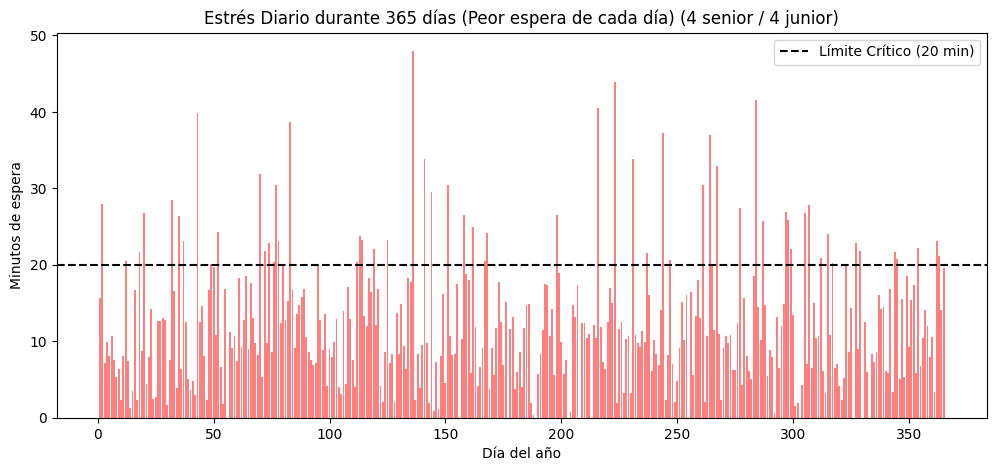

--- ANÁLISIS ANUAL ---
Total de personas atendidas al año: 46387
Total de personas que esperaron MÁS de 20 min: 504
Porcentaje de insatisfacción: 1.09%
Días con al menos un 'colapso' (>20 min): 61 de 365


In [14]:
# 1. Configuración
n_dias = 365  # Un año completo
equipo_a_probar = config_asesores_8_mixtos_1
resultados_por_dia = []
total_personas_espera_larga = 0
total_personas_atendidas = 0

for i in range(n_dias):
    # Generamos un día de trabajo
    llegadas = generacion_llegadas(15, pesos_dia)
    esperas = simulacion_atencion(equipo_a_probar, llegadas)
    
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # A. Guardamos la peor espera del día para la gráfica
        resultados_por_dia.append(max(esperas_minutos))
        
        # B. CONTAMOS PERSONAS: ¿Cuántos clientes hoy esperaron más de 20 min?
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # C. Acumulamos totales
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_dias + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(y=20, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_dias} días (Peor espera de cada día) (4 senior / 4 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.show()

# 3. Resultados exactos
print(f"--- ANÁLISIS ANUAL ---")
print(f"Total de personas atendidas al año: {total_personas_atendidas}")
print(f"Total de personas que esperaron MÁS de 20 min: {total_personas_espera_larga}")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")
print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_dias}")

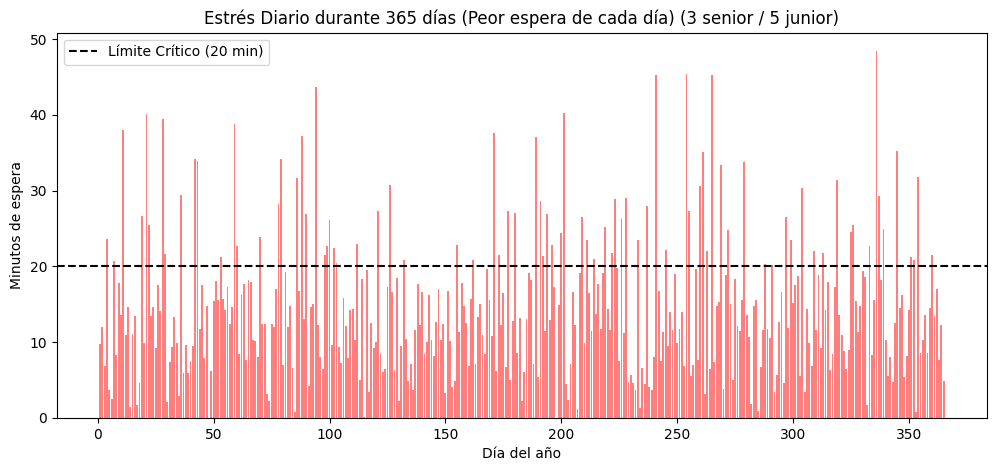

--- ANÁLISIS ANUAL ---
Total de personas atendidas al año: 46735
Total de personas que esperaron MÁS de 20 min: 863
Porcentaje de insatisfacción: 1.85%
Días con al menos un 'colapso' (>20 min): 83 de 365


In [15]:
# 1. Configuración
n_dias = 365  # Un año completo
equipo_a_probar = config_asesores_8_mixtos_2
resultados_por_dia = []
total_personas_espera_larga = 0
total_personas_atendidas = 0

for i in range(n_dias):
    # Generamos un día de trabajo
    llegadas = generacion_llegadas(15, pesos_dia)
    esperas = simulacion_atencion(equipo_a_probar, llegadas)
    
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # A. Guardamos la peor espera del día para la gráfica
        resultados_por_dia.append(max(esperas_minutos))
        
        # B. CONTAMOS PERSONAS: ¿Cuántos clientes hoy esperaron más de 20 min?
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # C. Acumulamos totales
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_dias + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(y=20, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_dias} días (Peor espera de cada día) (3 senior / 5 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.show()

# 3. Resultados exactos
print(f"--- ANÁLISIS ANUAL ---")
print(f"Total de personas atendidas al año: {total_personas_atendidas}")
print(f"Total de personas que esperaron MÁS de 20 min: {total_personas_espera_larga}")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")
print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_dias}")

In [16]:
df_Equipos_mixtos2

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.46,3.00,1320,192.77,1512.77,0.678191
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",11.52,10.25,1320,1186.89,2506.89,0.904255
2,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.26,1.65,1440,99.27,1539.27,0.612981
3,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.71,4.97,1440,582.81,2022.81,0.817308
4,Mixto (3 senior / 5 junior) base,500,15,8,3.06,35,"L=15, S=8, Mu=3.1",1.56,1.91,1320,121.91,1441.91,0.650510
5,Mixto (3 senior / 5 junior) alta demanda,500,20,8,3.06,35,"L=20, S=8, Mu=3.1",9.14,7.69,1320,939.45,2259.45,0.867347


De esta manera queda muy claro el hecho de que el equipo de 4 senior y 4 junior es el mas rentable y además es el que garatiza que cada año menos días se supere el limite critico maximo y que menos personas esperen mas de 20 minutos cualquier día

# Segunda parte: Umbral maximo de llegadas que puede soportar el equipo sin estallar

Tal y como hemos visto, el equipo de 4 senior y 4 junior el sistema con una tasa media de 15 llegadas por hora es el mas rentable y el mas eficiente entonces ahora lo vamos a poner en situaciones extremas a ver como se comporta en distintos ambitos